# Stage 6 - Deep Learning With PyTorch

Import required libraries

In [98]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from collections import Counter
import ast

In [99]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Some practice with pytorch before we start.

In [100]:
x = torch.tensor([1,2,3])
y = torch.tensor([4,5,6])

print(x+y)
print(x*y)
print(x.sum())
print(x.mean(dtype=torch.float32))

arr = np.array([1,2,3])
z = torch.from_numpy(arr)

z.shape


tensor([5, 7, 9])
tensor([ 4, 10, 18])
tensor(6)
tensor(2.)


torch.Size([3])

In [101]:
x_grad = torch.tensor(3.0, requires_grad=True)

y_grad = x_grad ** 2

y_grad.backward()

print(x_grad.grad)

tensor(6.)


Lets try some actual data now.

In [102]:
df = pd.read_csv('data/movies_clean.csv')
df.drop(columns=df.columns[0], inplace=True)
df['made_profit'] = (df['profit'] > 0).astype(int)

In [103]:
class SimpleClassifier(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, 16)
        self.layer2 = nn.Linear(16, 1)

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.sigmoid(self.layer2(x))
        return x

With the neural network made, lets test it with some data.

In [104]:
X = df.select_dtypes(include='number')
X = X.drop(['id', 'revenue', 'profit', 'made_profit'], axis=1)
y = df['made_profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=42)
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train, y_train, random_state=42, test_size=0.2)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.fit_transform(X_val)
X_test_scaled = scaler.fit_transform(X_test)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
y_train_tensor = torch.tensor(y_train_final.values, dtype=torch.float32).reshape(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

input_size = X_train_final.shape[1]

model = SimpleClassifier(input_size)

In [105]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 15
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    optimizer.zero_grad()
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    with torch.no_grad():
        val_predictions = model(X_val_tensor)
        val_loss = criterion(val_predictions, y_val_tensor)
        val_losses.append(val_loss.item())
        
    print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.6656114459037781
Epoch 1, Loss: 0.6643871068954468
Epoch 2, Loss: 0.6631672978401184
Epoch 3, Loss: 0.661952555179596
Epoch 4, Loss: 0.6607417464256287
Epoch 5, Loss: 0.6595327854156494
Epoch 6, Loss: 0.6583269238471985
Epoch 7, Loss: 0.6571252346038818
Epoch 8, Loss: 0.6559233069419861
Epoch 9, Loss: 0.6547212600708008
Epoch 10, Loss: 0.6535215973854065
Epoch 11, Loss: 0.6523218154907227
Epoch 12, Loss: 0.6511222720146179
Epoch 13, Loss: 0.6499238610267639
Epoch 14, Loss: 0.6487263441085815


<function matplotlib.pyplot.show(close=None, block=None)>

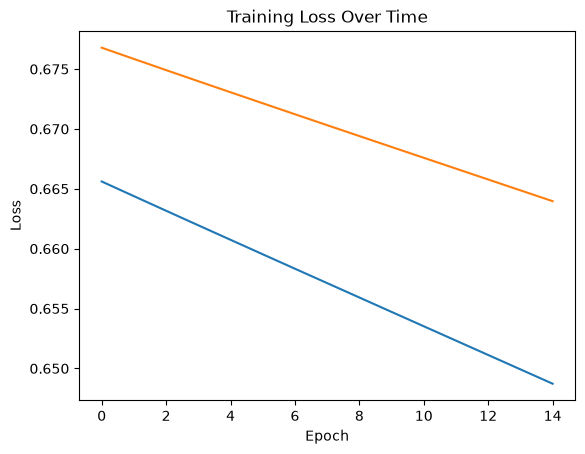

In [106]:
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.savefig('images/loss_over_time')
plt.show

In [107]:
with torch.no_grad():
    test_probs = model(X_test_tensor)
    test_predictions = (test_probs >= 0.5).float().numpy().flatten()

nn_accuracy = accuracy_score(y_test, test_predictions)
print(f"Neural network accuracy: {nn_accuracy}")

Neural network accuracy: 0.6565104166666667


Here we see that the model is only barely more accurate than justing taking a random guess. This is a limitation due to the data and difficulty of making predictions like this. While it would be nice to see a model that picks up on every small trend, the data it is given does not neccesarily give enough information to confidently determine if a movie will make profit or not. Next we will create another neural network for the sentiment data.

In [108]:
class SentimentAnalyzer(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        out = torch.sigmoid(self.fc(hidden[-1]))
        return out

In [109]:
train_df = pd.read_csv('data/tokenized_train.csv')
test_df = pd.read_csv('data/tokenized_test.csv')
train_df['tokens'] = train_df['tokens'].apply(ast.literal_eval)
test_df['tokens'] = test_df['tokens'].apply(ast.literal_eval)
all_words = [word for review in train_df['tokens'] for word in review]
word_counts = Counter(all_words)
vocab = {word: idx + 1 for idx, (word, count) in enumerate(word_counts.most_common())}

In [110]:
def encode(tokens):
    return [vocab.get(word, 0) for word in tokens]

In [111]:
def pad_sequence(seq, max_length):
    if len(seq) >= max_length:
        return seq[:max_length]
    return seq + [0] * (max_length - len(seq))

In [ ]:
max_length = 200

train_df_final, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

X_train_encoded = [pad_sequence(encode(tokens), max_length) for tokens in train_df_final['tokens']]
X_train_tensor = torch.tensor(X_train_encoded, dtype=torch.long).to(device)
y_train_tensor = torch.tensor(train_df_final['label'].values, dtype=torch.float).reshape(-1, 1).to(device)

X_val_encoded = [pad_sequence(encode(tokens), max_length) for tokens in val_df['tokens']]
X_val_tensor = torch.tensor(X_val_encoded, dtype=torch.long).to(device)
y_val_tensor = torch.tensor(val_df['label'].values, dtype=torch.float).reshape(-1, 1).to(device)

X_test_encoded = [pad_sequence(encode(tokens), max_length) for tokens in test_df['tokens']]
X_test_tensor = torch.tensor(X_test_encoded, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(test_df['label'], dtype=torch.float).reshape(-1, 1).to(device)

In [118]:
vocab_size = len(vocab) + 1
model = SentimentAnalyzer(vocab_size, embedding_dim=100, hidden_dim=64)
model = model.to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)

num_epochs = 6
batch_size = 32
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    epoch_loss = 0
    for i in range(0, len(X_train_tensor), batch_size):
        X_batch = X_train_tensor[i:i+batch_size]
        y_batch = y_train_tensor[i:i+batch_size]

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / (len(X_train_tensor) / batch_size)
    train_losses.append(avg_train_loss)

    val_loss_total = 0
    num_val_batches = 0
    with torch.no_grad():
        for i in range(0, len(X_val_tensor), batch_size):
            X_val_batch = X_val_tensor[i:i+batch_size]
            y_val_batch = y_val_tensor[i:i+batch_size]
            val_predictions = model(X_val_batch)
            val_loss = criterion(val_predictions, y_val_batch)
            val_loss_total += val_loss.item()
            num_val_batches += 1
    avg_val_loss = val_loss_total / num_val_batches
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

Epoch 0, Train Loss: 0.6933, Val Loss: 0.6932
Epoch 1, Train Loss: 0.6910, Val Loss: 0.6965
Epoch 2, Train Loss: 0.6848, Val Loss: 0.6935
Epoch 3, Train Loss: 0.6644, Val Loss: 0.6647
Epoch 4, Train Loss: 0.5071, Val Loss: 0.4854
Epoch 5, Train Loss: 0.3318, Val Loss: 0.4372


In [114]:
all_predictions = []

with torch.no_grad():
    for i in range(0, len(X_test_tensor), batch_size):
        X_batch = X_test_tensor[i:i+batch_size]
        batch_probs = model(X_batch)
        batch_predictions = (batch_probs >= 0.5).float()
        all_predictions.append(batch_predictions.cpu())

test_predictions = torch.cat(all_predictions).numpy()
lstm_accuracy = accuracy_score(test_df['label'], test_predictions)
print(f"LSTM test accuracy: {lstm_accuracy}")

LSTM test accuracy: 0.8208


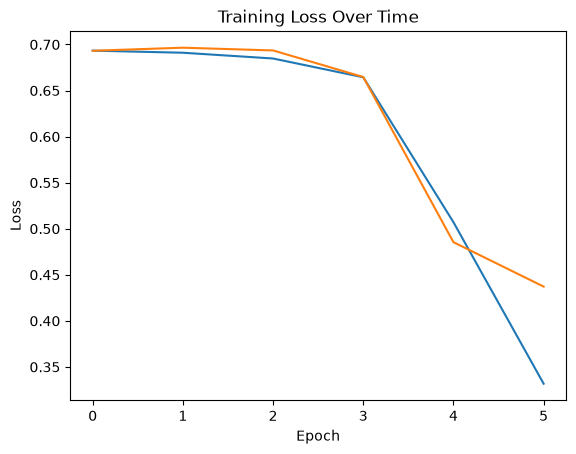

In [120]:
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.savefig('images/loss_over_time.png')
plt.show()


As we can see, this model performs quite decent on the data. With an accuracy of 82%, it is a generally good tell of whether a review is positive or not. However, this model performs 6 points worse than a standard Tfid Vectorizer and Logistic Regression. This is due to the fact that the embeddings are being trained on only what is in this dataset, instead of gaining valuable sentimental data from billions of words of text.